<a href="https://colab.research.google.com/github/heemene/COGS109GROUPA/blob/main/COGS109_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Below is the setup to import the datasets into Google Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix

eda

In [ ]:
file_path = '/content/drive/MyDrive/inczipcity.csv'
df = pd.read_csv(file_path)
df.head()


,Zip Code,Community,Estimated Median Income
0,90001,"Los Angeles (South Los Angeles), Florence-Graham","$33,887"
1,90002,"Los Angeles (Southeast Los Angeles, Watts)","$30,413"
2,90003,"Los Angeles (South Los Angeles, Southeast Los ...","$30,805"
3,90004,"Los Angeles (Hancock Park, Rampart Village, Vi...","$40,612"
4,90005,"Los Angeles (Hancock Park, Koreatown, Wilshire...","$31,142"


In [ ]:
df = pd.read_csv("/content/drive/My Drive/grocery store.csv")
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])


n, p = df.shape
print(f"n (rows): {n}")
print(f"p (columns): {p}")
df.head()




n (rows): 1231
p (columns): 16


,LOCATION ACCOUNT #,BUSINESS NAME,DBA NAME,STREET ADDRESS,CITY,ZIP CODE,LOCATION DESCRIPTION,MAILING ADDRESS,MAILING CITY,MAILING ZIP CODE,NAICS,PRIMARY NAICS DESCRIPTION,COUNCIL DISTRICT,LOCATION START DATE,LOCATION END DATE,LOCATION
0,0000003004-0001-9,SUPER A FOODS INC,SUPER A FOODS,2925 DIVISION STREET,LOS ANGELES,90065-1215,2925 DIVISION 90065-1215,7200 DOMINION CIRCLE,COMMERCE,90040-3647,445100,Grocery stores (including supermarkets & conve...,1,01/02/1972,NaN,POINT (-118.2356 34.1029)
1,0000003004-0003-5,SUPER A FOODS INC,SUPER A FOODS,5250 YORK BLVD,LOS ANGELES,90042-1744,5250 YORK 90042-1744,7200 DOMINION CIRCLE,COMMERCE,90040-3647,445100,Grocery stores (including supermarkets & conve...,14,07/29/1999,NaN,POINT (-118.2015 34.1204)
2,0000003718-0001-8,GLATT WESTERN KOSHER INC,GLATT WESTERN KOSHER,444 N FAIRFAX AVENUE,LOS ANGELES,90036-1717,444 FAIRFAX 90036-1717,POST OFFICE BOX #219088,LOS ANGELES,75221-9088,445100,Grocery stores (including supermarkets & conve...,5,02/17/1992,NaN,POINT (-118.3614 34.0792)
3,0000003718-0002-6,GLATT WESTERN KOSHER INC,ANGELICAS MARKET,4817 W PICO BLVD,LOS ANGELES,90019-4226,4817 PICO 90019-4226,POST OFFICE BOX #219088,LOS ANGELES,75221-9088,445100,Grocery stores (including supermarkets & conve...,10,03/01/2012,NaN,POINT (-118.3413 34.0482)
4,0000003971-0001-4,LA TROPICANA MARKET INC,LA TROPICANA MARKET,5200 MONTE VISTA STREET,LOS ANGELES,90042-4015,5200 MONTE VISTA 90042-4015,POST OFFICE BOX #219088,LOS ANGELES,75221-9088,445100,Grocery stores (including supermarkets & conve...,1,06/16/2003,NaN,POINT (-118.201 34.1084)


Grocery Store Data (first 5 rows):


<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3514148733.py:20: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)  # remove $ and commas


,LOCATION ACCOUNT #,BUSINESS NAME,DBA NAME,STREET ADDRESS,CITY,ZIP CODE,LOCATION DESCRIPTION,MAILING ADDRESS,MAILING CITY,MAILING ZIP CODE,NAICS,PRIMARY NAICS DESCRIPTION,COUNCIL DISTRICT,LOCATION START DATE,LOCATION END DATE,LOCATION
0,0000003004-0001-9,SUPER A FOODS INC,SUPER A FOODS,2925 DIVISION STREET,LOS ANGELES,90065-1215,2925 DIVISION 90065-1215,7200 DOMINION CIRCLE,COMMERCE,90040-3647,445100,Grocery stores (including supermarkets & conve...,1,01/02/1972,NaN,POINT (-118.2356 34.1029)
1,0000003004-0003-5,SUPER A FOODS INC,SUPER A FOODS,5250 YORK BLVD,LOS ANGELES,90042-1744,5250 YORK 90042-1744,7200 DOMINION CIRCLE,COMMERCE,90040-3647,445100,Grocery stores (including supermarkets & conve...,14,07/29/1999,NaN,POINT (-118.2015 34.1204)
2,0000003718-0001-8,GLATT WESTERN KOSHER INC,GLATT WESTERN KOSHER,444 N FAIRFAX AVENUE,LOS ANGELES,90036-1717,444 FAIRFAX 90036-1717,NaN,NaN,NaN,445100,Grocery stores (including supermarkets & conve...,5,02/17/1992,NaN,POINT (-118.3614 34.0792)
3,0000003718-0002-6,GLATT WESTERN KOSHER INC,NaN,4817 W PICO BLVD,LOS ANGELES,90019-4226,4817 PICO 90019-4226,NaN,NaN,NaN,445100,Grocery stores (including supermarkets & conve...,10,03/01/2012,NaN,POINT (-118.3413 34.0482)
4,0000003971-0001-4,LA TROPICANA MARKET INC,LA TROPICANA MARKET,5200 MONTE VISTA STREET,LOS ANGELES,90042-4015,5200 MONTE VISTA 90042-4015,NaN,NaN,NaN,445100,Grocery stores (including supermarkets & conve...,1,06/16/2003,NaN,POINT (-118.201 34.1084)



Income by ZIP Data (first 5 rows):


,Zip Code,Community,Estimated Median Income
0,90001,"Los Angeles (South Los Angeles), Florence-Graham","$33,887"
1,90002,"Los Angeles (Southeast Los Angeles, Watts)","$30,413"
2,90003,"Los Angeles (South Los Angeles, Southeast Los ...","$30,805"
3,90004,"Los Angeles (Hancock Park, Rampart Village, Vi...","$40,612"
4,90005,"Los Angeles (Hancock Park, Koreatown, Wilshire...","$31,142"


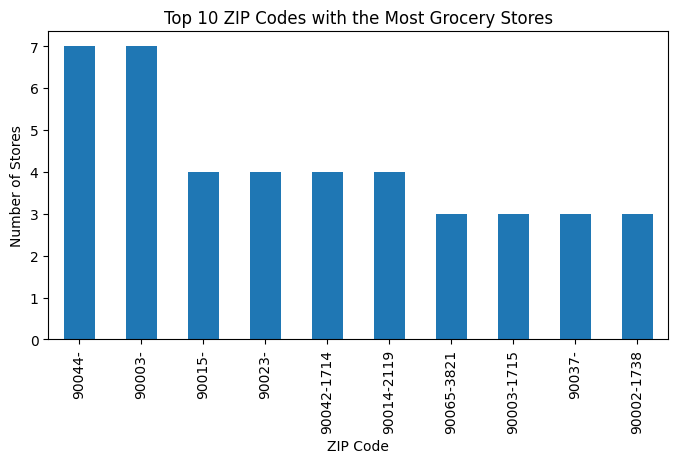

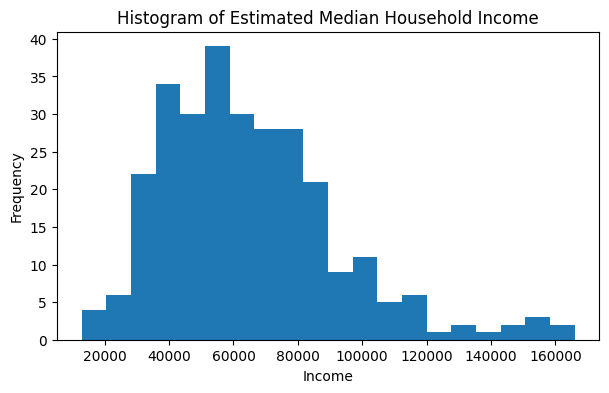

In [45]:
grocery = pd.read_csv("/content/drive/MyDrive/grocery store.csv")
income = pd.read_csv("/content/drive/MyDrive/inczipcity.csv")

print("Grocery Store Data (first 5 rows):")
display(grocery.head())
print("\nIncome by ZIP Data (first 5 rows):")
display(income.head())

#top10store
plt.figure(figsize=(8,4))
grocery['ZIP CODE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 ZIP Codes with the Most Grocery Stores")
plt.xlabel("ZIP Code")
plt.ylabel("Number of Stores")
plt.show()

#incomedata
income['Estimated Median Income'] = (
    income['Estimated Median Income']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

#histogram
plt.figure(figsize=(7,4))
income['Estimated Median Income'].plot(kind='hist', bins=20)
plt.title("Histogram of Estimated Median Household Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()



In [38]:
grocery = pd.read_csv("/content/drive/MyDrive/grocery store.csv")
grocery = grocery[['ZIP CODE', 'BUSINESS NAME']]

grocery['ZIP CODE'] = grocery['ZIP CODE'].astype(str).str[:5]
print("Cleaned Grocery Store Data (first 5 rows):")
display(grocery.head())


Cleaned Grocery Store Data (first 5 rows):


,ZIP CODE,BUSINESS NAME
0,90065,SUPER A FOODS INC
1,90042,SUPER A FOODS INC
2,90036,GLATT WESTERN KOSHER INC
3,90019,GLATT WESTERN KOSHER INC
4,90042,LA TROPICANA MARKET INC


In [ ]:
# cleaned grocery dataset
grocery = grocery[['ZIP CODE', 'BUSINESS NAME']]
grocery['ZIP CODE'] = grocery['ZIP CODE'].astype(str).str[:5]
store_counts = grocery.groupby('ZIP CODE')['BUSINESS NAME'].count().reset_index()


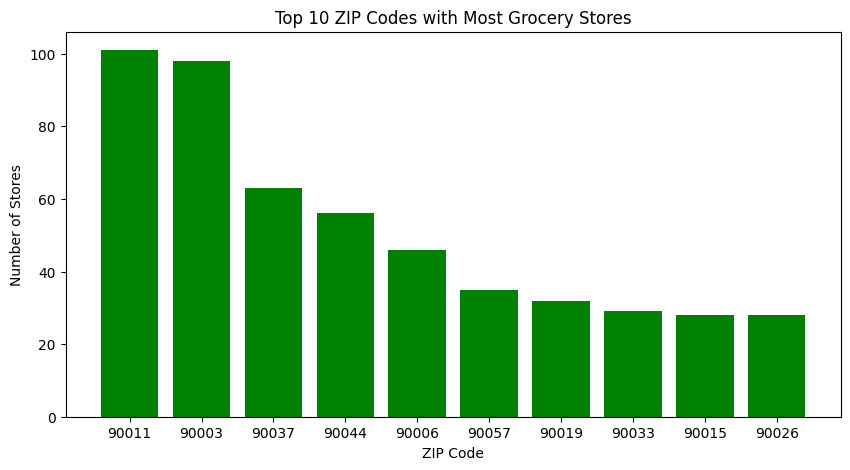

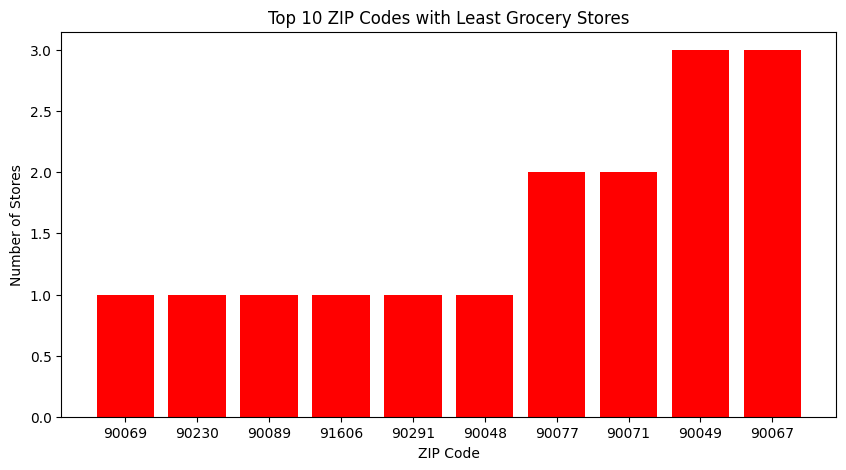

In [ ]:
#top10
top10 = store_counts.sort_values(by='Store Count', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['ZIP CODE'], top10['Store Count'], color='green')
plt.title("Top 10 ZIP Codes with Most Grocery Stores")
plt.xlabel("ZIP Code")
plt.ylabel("Number of Stores")
plt.show()

#bottom10
nonzero_stores = store_counts[store_counts['Store Count'] > 0]
bottom10 = nonzero_stores.sort_values(by='Store Count').head(10)

plt.figure(figsize=(10,5))
plt.bar(bottom10['ZIP CODE'], bottom10['Store Count'], color='red')
plt.title("Top 10 ZIP Codes with Least Grocery Stores")
plt.xlabel("ZIP Code")
plt.ylabel("Number of Stores")
plt.show()




baseline model, log transform, and ridge models

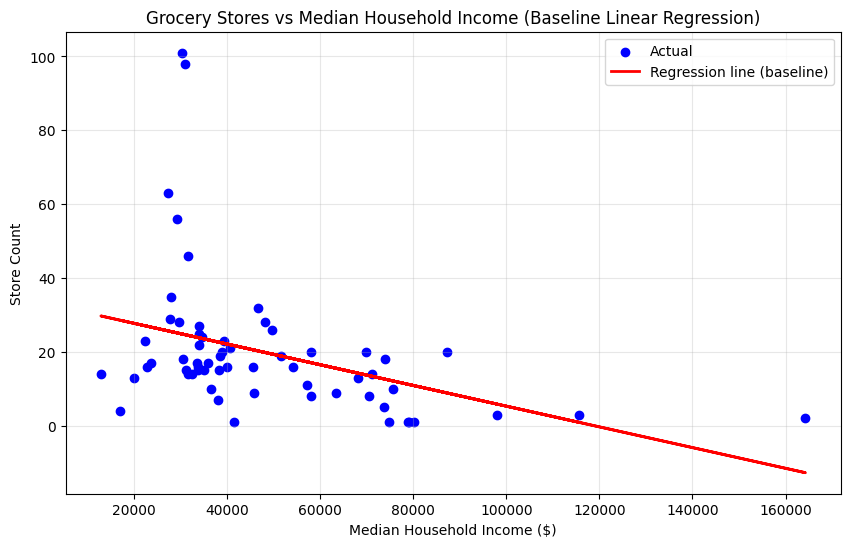

In [71]:
#baseline
plt.figure(figsize=(10, 6))
plt.scatter(
    X, y,
    color='blue',
    label='Actual'
)

# Regression line
plt.plot(
    X, y_pred1,
    color='red',
    linewidth=2,
    label='Regression line (baseline)'
)
plt.title("Grocery Stores vs Median Household Income (Baseline Linear Regression)")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Store Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


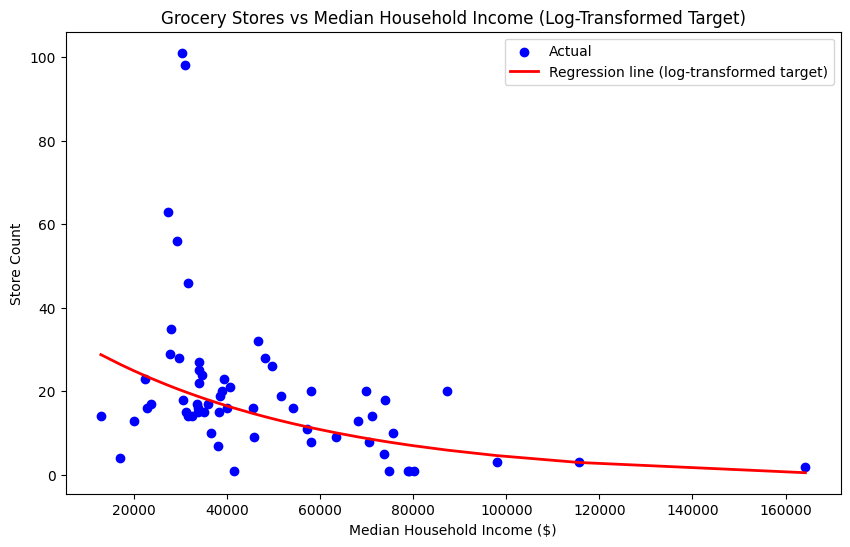

In [70]:
#logtransform
y_log = np.log1p(y)
model = LinearRegression()
model.fit(X, y_log)
y_log_pred = model.predict(X)
y_pred_original = np.expm1(y_log_pred)   # inverse of log1p

#plot
plt.figure(figsize=(10, 6))

plt.scatter(X, y, label='Actual', color='blue')
sorted_idx = np.argsort(X.values[:, 0])
plt.plot(
    X.values[sorted_idx],
    y_pred_original[sorted_idx],
    color='red',
    linewidth=2,
    label='Regression line (log-transformed target)'
)

plt.title("Grocery Stores vs Median Household Income (Log-Transformed Target)")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Store Count")
plt.legend()
plt.show()

R² score: 0.10428081138014189
RMSE: 24.120175440747797


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


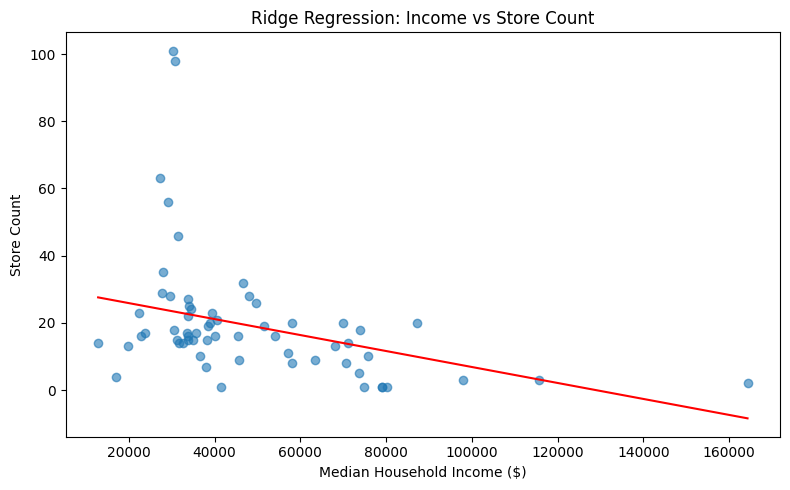

In [69]:
#ridge regression
df = merged.copy()
df = df.dropna(subset=["Estimated Median Income", "Store Count"])

X = df[["Estimated Median Income"]]
y = df["Store Count"]

#80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("R² score:", r2)
print("RMSE:", rmse)

#plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Estimated Median Income"],
    df["Store Count"],
    alpha=0.6
)


income_range = np.linspace(df["Estimated Median Income"].min(),
                           df["Estimated Median Income"].max(), 300).reshape(-1, 1)
ridge_line = ridge.predict(income_range)

plt.plot(income_range, ridge_line, color='red')
plt.xlabel("Median Household Income ($)")
plt.ylabel("Store Count")
plt.title("Ridge Regression: Income vs Store Count")
plt.tight_layout()
plt.show()


comparison metrics

AIC:
     base: 357.46
     log: -15.79
     ridge: 357.46


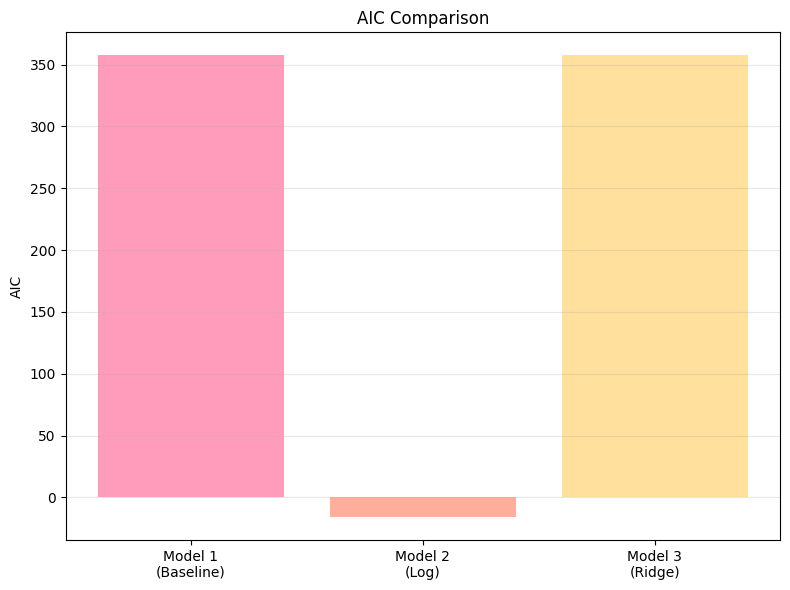

In [62]:
df = merged.copy()
df = df.dropna(subset=["Estimated Median Income", "Store Count"])
X = df[["Estimated Median Income"]]
y = df["Store Count"]
n = len(y)
k = 2


model1 = LinearRegression()
y_log = np.log(y)
model3 = Ridge(alpha=1.0)

#base
model1.fit(X, y)
aic1 = n * np.log(rss1/n) + 2*k

#logtransform
model2 = LinearRegression()
aic2 = n * np.log(rss2/n) + 2*k

#ridge
model3.fit(X, y)
aic3 = n * np.log(rss3/n) + 2*k


# AIC comparison
aic_values = {'base': aic1, 'log': aic2, 'ridge': aic3}
print(f"AIC:")
for name, val in aic_values.items():
    print(f"     {name}: {val:.2f}")


fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(model_names, [aic1, aic2, aic3],
       color=['#FF9CBB', '#FFAE9C', '#FFE09C'])

ax.set_ylabel('AIC')
ax.set_title('AIC Comparison')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Adjusted R²:
     base: 0.1357
     log: 0.3179
     ridge: 0.1357


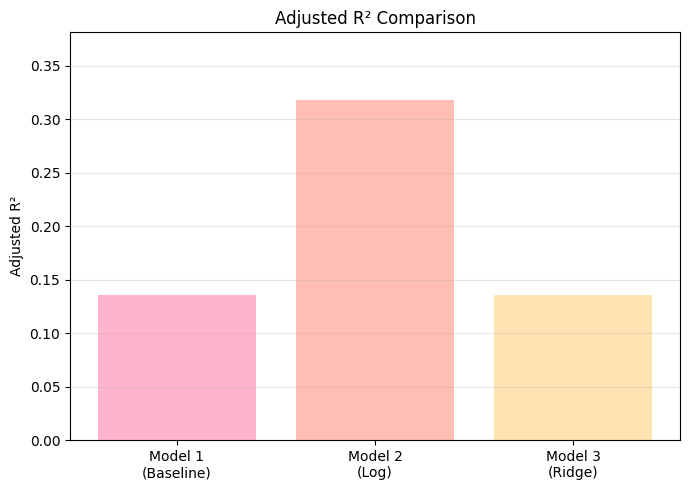

In [63]:
df = merged.copy()
df = df.dropna(subset=["Estimated Median Income", "Store Count"])
X = df[["Estimated Median Income"]]
y = df["Store Count"]
n = len(y)
k = 2

#base
model1.fit(X, y)
adj_r2_1 = 1 - (1 - r2_1) * (n - 1) / (n - k)

#log
model2 = LinearRegression()
model2.fit(X, y_log)
adj_r2_2 = 1 - (1 - r2_2) * (n - 1) / (n - k)

#ridge
model3.fit(X, y)
adj_r2_3 = 1 - (1 - r2_3) * (n - 1) / (n - k)

#plot
adj_r2_values = {'base': adj_r2_1, 'log': adj_r2_2, 'ridge': adj_r2_3}
print("Adjusted R²:")
for name, val in adj_r2_values.items():
    print(f"     {name}: {val:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(model_names, [adj_r2_1, adj_r2_2, adj_r2_3],
       color=['#FFB3CE', '#FFBEB3', '#FFE4B3'])
ax.set_ylabel('Adjusted R²')
ax.set_title('Adjusted R² Comparison')
ax.set_ylim([0, max(adj_r2_1, adj_r2_2, adj_r2_3) * 1.2])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
